# Text Mining Project — Data Exploration
**Spring Semester 2025/2026**

Group 11:
- Ana Macedo
- Carlota Pires
- Francisca Calçoa
- Francisca Martins

This notebook covers **Section 1 – Data Exploration** of the project requirements.


## 1. Imports and Setup

In [1]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Load the Data

In [2]:
train = pd.read_csv('../Datasets/train.csv')
test  = pd.read_csv('../Datasets/test.csv')

In [3]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Label mapping for readability
label_map  = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
label_colors = {'Bearish': '#e58181', 'Bullish': '#c4ebc4', 'Neutral': '#fff3b1'}

# Add readable label column
train['sentiment'] = train['label'].map(label_map)

## 3. Basic Dataset Overview

In [4]:
#Verification of the loaded data
print(f'Train set : {train.shape[0]:,} tweets, {train.shape[1]} columns')
print(f'Test set  : {test.shape[0]:,} tweets, {test.shape[1]} columns')
train.head(10)

Train set : 9,543 tweets, 3 columns
Test set  : 2,388 tweets, 2 columns


,text,label,sentiment
0,$BYND - JPMorgan reels in expectations on Beyo...,0,Bearish
1,$CCL $RCL - Nomura points to bookings weakness...,0,Bearish
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,Bearish
3,$ESS: BTIG Research cuts to Neutral https://t....,0,Bearish
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0,Bearish
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0,Bearish
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0,Bearish
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0,Bearish
8,$GTT: Cowen cuts to Market Perform,0,Bearish
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0,Bearish


In [5]:
train.tail(10)

,text,label,sentiment
9533,"Stocks making the biggest moves midday: Tesla,...",2,Neutral
9534,"Stocks making the biggest moves midday: Tesla,...",2,Neutral
9535,"Stocks making the biggest moves midday: Uber, ...",2,Neutral
9536,Stocks making the biggest moves premarket: Tar...,2,Neutral
9537,Stocks making the biggest moves premarket: TD ...,2,Neutral
9538,The Week's Gainers and Losers on the Stoxx Eur...,2,Neutral
9539,Tupperware Brands among consumer gainers; Unil...,2,Neutral
9540,vTv Therapeutics leads healthcare gainers; Myo...,2,Neutral
9541,"WORK, XPO, PYX and AMKR among after hour movers",2,Neutral
9542,"YNDX, I, QD and OESX among tech movers",2,Neutral


In [6]:
print('Data Types:')
print(train.dtypes)
print()
print('Missing Values:')
print(train.isnull().sum())
print()
print('Test Set Columns:')
print(test.columns.tolist())
print(test.head(3))

Data Types:
text         object
label         int64
sentiment    object
dtype: object

Missing Values:
text         0
label        0
sentiment    0
dtype: int64

Test Set Columns:
['id', 'text']
   id                                               text
0   0  ETF assets to surge tenfold in 10 years to $50...
1   1  Here’s What Hedge Funds Think Evolution Petrol...
2   2  $PVH - Phillips-Van Heusen Q3 2020 Earnings Pr...


In [7]:
print(train['label'].describe())
print(f"\nUnique values: {sorted(train['label'].unique())}")

count    9543.000000
mean        1.496280
std         0.743139
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         2.000000
Name: label, dtype: float64

Unique values: [np.int64(0), np.int64(1), np.int64(2)]


## 4. Class Distribution

Understanding class balance is critical: if one class dominates, a naive classifier that always predicts that class will have artificially high accuracy.

In [8]:
counts = train['label'].value_counts().sort_index()
total  = len(train)

print('Class distribution (training set):')
for label, count in counts.items():
    name = label_map[label]
    print(f'  {name:8s} ({label}): {count:,}  ({count / total * 100:.1f}%)')

majority_acc = counts.max() / total * 100
print(f'\nMajority-class baseline accuracy: {majority_acc:.1f}%')
print('-> A model must beat this to be useful.')

Class distribution (training set):
  Bearish  (0): 1,442  (15.1%)
  Bullish  (1): 1,923  (20.2%)
  Neutral  (2): 6,178  (64.7%)

Majority-class baseline accuracy: 64.7%
-> A model must beat this to be useful.


**Conclusions:**
- The dataset is imbalanced: ~64.7% of tweets are Neutral, while Bearish (15.1%) and Bullish (20.2%) are underrepresented.
- The majority-class baseline achieves ~64.7% accuracy.
- Class imbalance must be addressed during preprocessing and modelling through for example class weights or oversampling.

In [9]:
train['word_count'] = train['text'].apply(lambda x: len(str(x).split()))
train['char_count'] = train['text'].apply(lambda x: len(str(x)))

print('Word count statistics by class:')
print(train.groupby('sentiment')['word_count'].describe().round(2))

Word count statistics by class:
            count   mean   std  min  25%   50%   75%   max
sentiment                                                 
Bearish    1442.0  12.00  4.31  3.0  9.0  11.0  15.0  32.0
Bullish    1923.0  11.93  4.32  2.0  9.0  11.0  14.0  29.0
Neutral    6178.0  12.30  4.84  1.0  9.0  12.0  16.0  29.0


**Conclusion:** Tweets are generally short (~12 words on average), consistent across all three classes.


/var/folders/fw/9q_f59b1297dqq04tft8hv1c0000gn/T/ipykernel_25314/3385815743.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


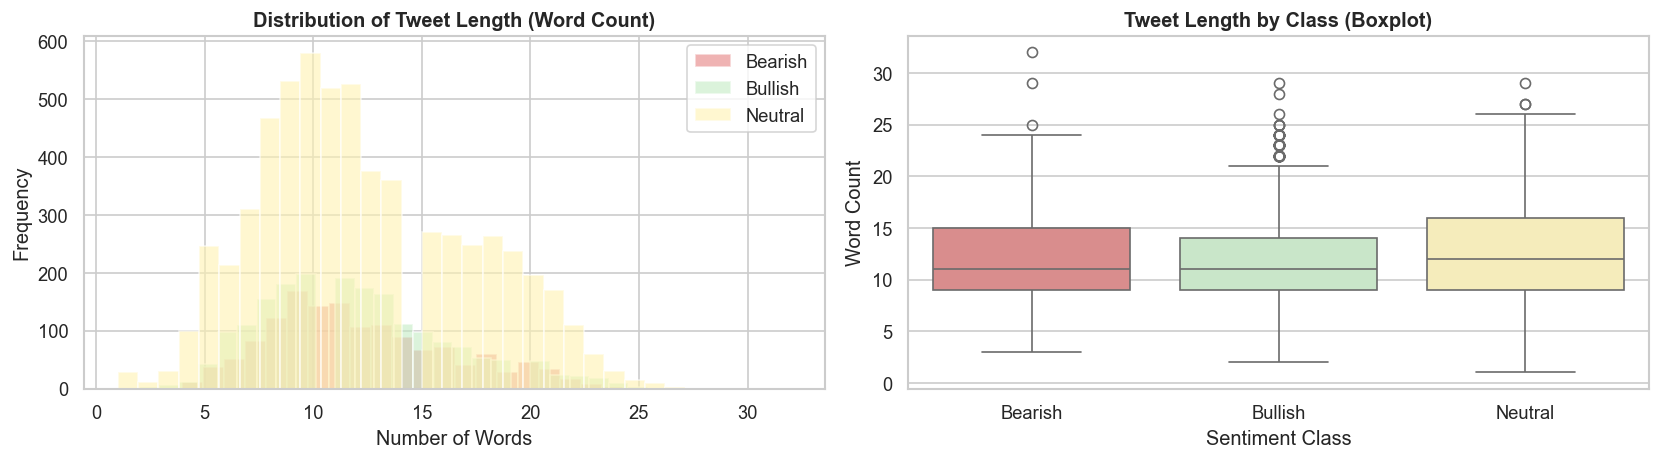

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label_id, label_name in label_map.items():
    subset = train[train['label'] == label_id]['word_count']
    axes[0].hist(subset, bins=30, alpha=0.6, label=label_name,
                 color=label_colors[label_name],
                 edgecolor='white')

axes[0].set_title('Distribution of Tweet Length (Word Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.boxplot(
    data=train, x='sentiment', y='word_count',
    palette=label_colors,
    order=['Bearish', 'Bullish', 'Neutral'],
    ax=axes[1]
)

axes[1].set_title('Tweet Length by Class (Boxplot)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment Class')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('tweet_length.png', bbox_inches='tight')
plt.show()

In [11]:
train['has_ticker']  = train['text'].apply(lambda x: bool(re.search(r'\$[A-Z]{1,5}', x)))
train['has_hashtag'] = train['text'].apply(lambda x: bool(re.search(r'#\w+', x)))
train['has_url']     = train['text'].apply(lambda x: bool(re.search(r'http', x)))

feature_cols = ['has_ticker', 'has_hashtag', 'has_url']
feature_labels = ['Stock Ticker ($)', 'Hashtag (#)', 'URL (http)']

print('Presence of Twitter-specific features (% of tweets):')
for col, lbl in zip(feature_cols, feature_labels):
    print(f'  {lbl:20s}: {train[col].mean()*100:.1f}%')

Presence of Twitter-specific features (% of tweets):
  Stock Ticker ($)    : 15.0%
  Hashtag (#)         : 9.4%
  URL (http)          : 46.8%


**Conclusions:**
- Stock tickers like `$AAPL` and `$TSLA` appear in ~15% of tweets and are specific to financial sentiment
- Hashtags appear in ~9% of tweets, so their contribution to sentiment may vary.
- URLs are present in ~47% of tweets. They carry no semantic value and should be removed during preprocessing.

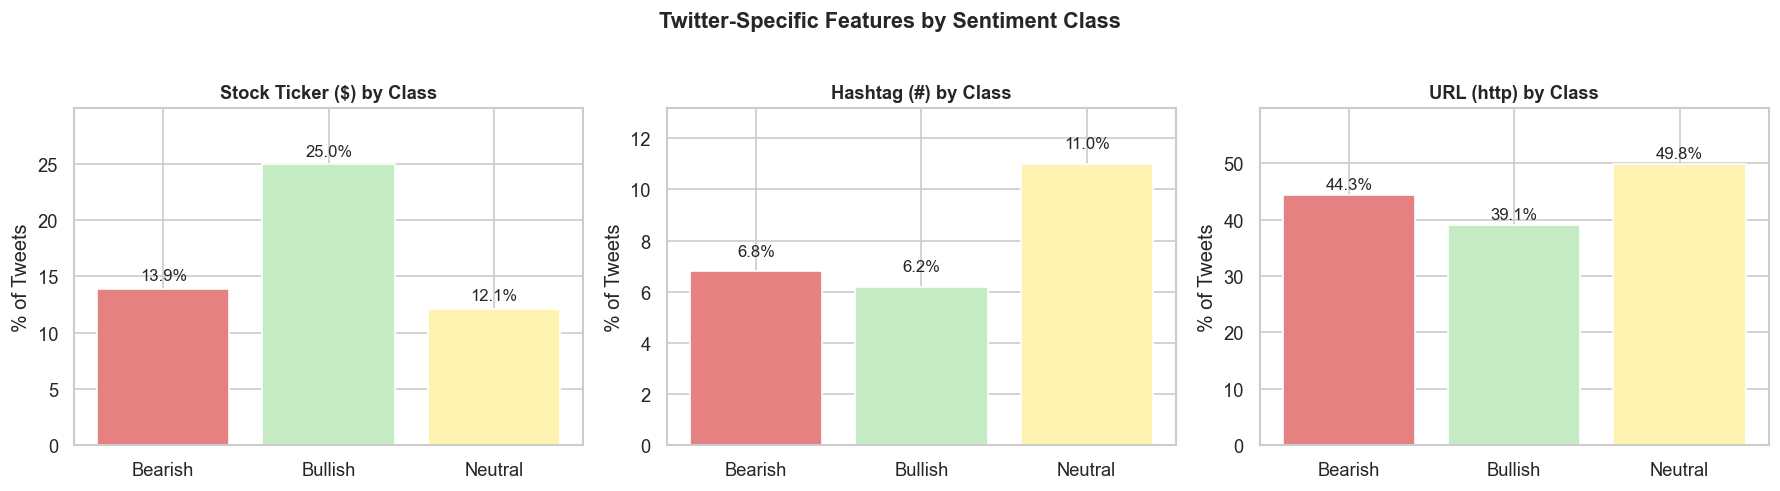

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, lbl in zip(axes, feature_cols, feature_labels):
    data = train.groupby('sentiment')[col].mean() * 100
    data = data.reindex(['Bearish', 'Bullish', 'Neutral'])
    colors = [label_colors[k] for k in ['Bearish', 'Bullish', 'Neutral']]
    bars = ax.bar(data.index, data.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'{lbl} by Class', fontsize=11, fontweight='bold')
    ax.set_ylabel('% of Tweets')
    ax.set_ylim(0, data.max() * 1.2)

plt.suptitle('Twitter-Specific Features by Sentiment Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('twitter_features.png', bbox_inches='tight')
plt.show()

**Conclusions:**
- Stock Tickers ($): Bullish has 25% vs Bearish 13.9%. This means that tweets with tickers are more associated with positive sentiment.
- Hashtags (#): Little difference between classes (6-11%), so they have low discriminative power.
- URLs (http): Appear a lot across all classes relatively uniformly, so they do not distinguish sentiment and should be removed in preprocessing. 

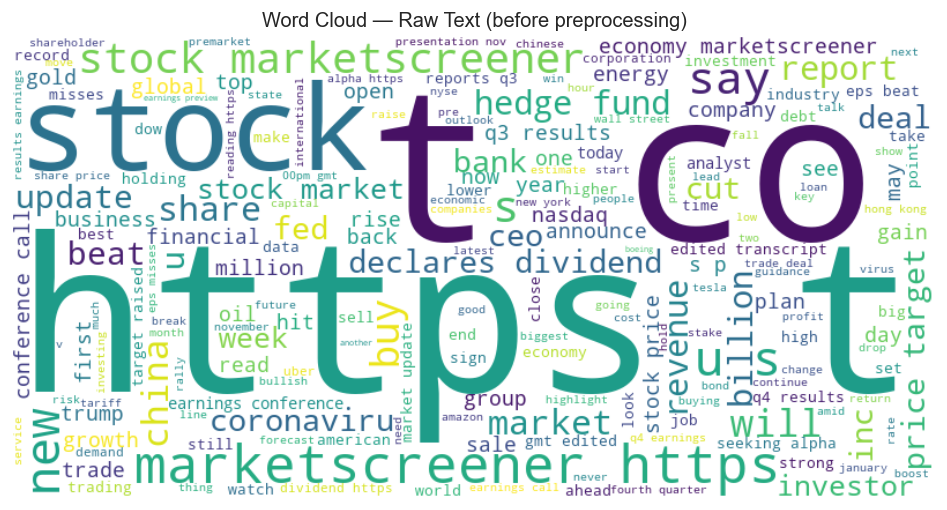

In [15]:
# Word Cloud — Raw Text (antes do pré-processamento)
raw_text = ' '.join(train['text'].fillna('')).lower()
raw_wc = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Raw Text (before preprocessing)')
plt.show()